# 📉 Revenue Leakage Detection & Pricing Optimization
### E-Commerce Dataset — Flipkart Product Listings
**Objective:** Identify where the business is losing revenue due to pricing inefficiencies,
excessive discounts, and out-of-stock situations. Recommend corrective actions.

---


## 1. Setup & Data Loading

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import sqlite3
import re
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#1A1A2E', 'axes.facecolor': '#16213E',
    'axes.edgecolor': '#444', 'axes.labelcolor': '#E0E0E0',
    'xtick.color': '#E0E0E0', 'ytick.color': '#E0E0E0',
    'text.color': '#E0E0E0', 'grid.color': '#2a2a4a',
    'grid.linestyle': '--', 'grid.alpha': 0.5, 'figure.dpi': 120,
})

df_raw = pd.read_excel('../data/flipkart_products.xlsx')
print(f"Shape: {df_raw.shape}")
df_raw.head(3)


Shape: (30000, 18)


,Unnamed: 0,_id,actual_price,average_rating,brand,category,crawled_at,description,discount,images,out_of_stock,pid,product_details,seller,selling_price,sub_category,title,url
0,0,fa8e22d6-c0b6-5229-bb9e-ad52eda39a0a,"2,999",3.9,York,Clothing and Accessories,"02/10/2021, 20:11:51",69% off,Yorker trackpants made from 100% rich combed c...,['https://rukminim1.flixcart.com/image/128/128...,False,TKPFCZ9EA7H5FYZH,"[{'Style Code': '1005COMBO2'}, {'Closure': 'El...",Shyam Enterprises,921,Bottomwear,Solid Men Multicolor Track Pants,https://www.flipkart.com/yorker-solid-men-mult...
1,1,893e6980-f2a0-531f-b056-34dd63fe912c,"1,499",3.9,York,Clothing and Accessories,"02/10/2021, 20:11:52",66% off,Yorker trackpants made from 100% rich combed c...,['https://rukminim1.flixcart.com/image/128/128...,False,TKPFCZ9EJZV2UVRZ,"[{'Style Code': '1005BLUE'}, {'Closure': 'Draw...",Shyam Enterprises,499,Bottomwear,Solid Men Blue Track Pants,https://www.flipkart.com/yorker-solid-men-blue...
2,2,eb4c8eab-8206-59d0-bcd1-a724d96bf74f,"2,999",3.9,York,Clothing and Accessories,"02/10/2021, 20:11:52",68% off,Yorker trackpants made from 100% rich combed c...,['https://rukminim1.flixcart.com/image/128/128...,False,TKPFCZ9EHFCY5Z4Y,"[{'Style Code': '1005COMBO4'}, {'Closure': 'El...",Shyam Enterprises,931,Bottomwear,Solid Men Multicolor Track Pants,https://www.flipkart.com/yorker-solid-men-mult...


## 2. Data Cleaning & Feature Engineering

In [2]:

def clean_price(val):
    if pd.isna(val): return np.nan
    return float(str(val).replace(',', '').strip())

def extract_discount_pct(val):
    if pd.isna(val): return np.nan
    m = re.search(r'(\d+)\s*%', str(val))
    return float(m.group(1)) if m else np.nan

df = df_raw.copy()
df = df.rename(columns={'description': 'discount_text', 'discount': 'product_description'})
df['actual_price']   = df['actual_price'].apply(clean_price)
df['selling_price']  = df['selling_price'].apply(clean_price)
df['discount_pct']   = df['discount_text'].apply(extract_discount_pct)

# Remove duplicates and nulls
df = df.drop_duplicates(subset=['pid']).dropna(subset=['actual_price','selling_price'])

# Derived columns
df['discount_amount']   = df['actual_price'] - df['selling_price']
df['discount_pct_calc'] = ((df['discount_amount'] / df['actual_price']) * 100).round(2)
df['revenue_at_risk']   = np.where(df['discount_pct_calc'] > 40, df['discount_amount'], 0)
df['high_discount_flag']= df['discount_pct_calc'] > 40
df['out_of_stock_loss'] = np.where(df['out_of_stock'], df['selling_price'], 0)
df['price_tier'] = pd.cut(
    df['selling_price'],
    bins=[0,500,1500,5000,np.inf],
    labels=['Budget','Mid','Premium','Luxury']
)
df['brand']      = df['brand'].str.strip().str.title()
df['category']   = df['category'].str.strip()
df['sub_category']= df['sub_category'].str.strip()

print(f"Clean dataset shape: {df.shape}")
print(f"Revenue at risk: ₹{df['revenue_at_risk'].sum():,.0f}")
print(f"Over-discounted: {df['high_discount_flag'].sum():,} ({df['high_discount_flag'].mean()*100:.1f}%)")
df.describe()[['actual_price','selling_price','discount_pct_calc','revenue_at_risk']]


Clean dataset shape: (27303, 25)
Revenue at risk: ₹18,205,117
Over-discounted: 20,532 (75.2%)


,actual_price,selling_price,discount_pct_calc,revenue_at_risk
count,27303.000000,27303.000000,27303.000000,27303.000000
mean,1455.528110,697.447240,50.474664,666.780830
std,939.977456,536.867083,17.132124,616.260935
min,150.000000,99.000000,0.000000,0.000000
25%,849.000000,385.000000,40.010000,198.000000
50%,1199.000000,531.000000,52.850000,574.000000
75%,1799.000000,816.000000,63.090000,1000.000000
max,12999.000000,7999.000000,87.170000,7800.000000


## 3. SQL Analysis (SQLite)

In [3]:

conn = sqlite3.connect(':memory:')
df.to_sql('products', conn, index=False, if_exists='replace')

def sql(query, title=""):
    if title: print(f"\n{'='*55}\n  {title}\n{'='*55}")
    result = pd.read_sql_query(query, conn)
    display(result)
    return result


In [4]:

# Q1: Revenue at risk by sub-category
q1 = sql('''
    SELECT sub_category, COUNT(*) products,
           ROUND(AVG(discount_pct_calc),1) avg_disc,
           ROUND(SUM(revenue_at_risk),0) revenue_at_risk
    FROM products WHERE high_discount_flag=1
    GROUP BY sub_category ORDER BY revenue_at_risk DESC LIMIT 10
''', "Q1: Revenue at Risk by Sub-Category")



  Q1: Revenue at Risk by Sub-Category


,sub_category,products,avg_disc,revenue_at_risk
0,Topwear,11561,58.8,9397579.0
1,Winter Wear,1945,56.6,2586217.0
2,Bottomwear,2405,55.2,2582102.0
3,Clothing Accessories,1373,60.4,919404.0
4,"Kurtas, Ethnic Sets and Bottoms",901,54.8,902964.0
5,Innerwear and Swimwear,802,60.4,493804.0
6,Fabrics,532,66.3,429368.0
7,Men's Footwear,673,62.3,375028.0
8,"Blazers, Waistcoats and Suits",88,58.9,276079.0
9,Sleepwear,93,52.8,69432.0


In [5]:

# Q2: Discount bucket analysis
q2 = sql('''
    WITH b AS (SELECT *,
        CASE WHEN discount_pct_calc<20 THEN '0-20%'
             WHEN discount_pct_calc<40 THEN '20-40%'
             WHEN discount_pct_calc<60 THEN '40-60%'
             WHEN discount_pct_calc<80 THEN '60-80%'
             ELSE '80%+' END AS bucket FROM products)
    SELECT bucket, COUNT(*) products, ROUND(AVG(selling_price),0) avg_price,
           ROUND(AVG(average_rating),2) avg_rating,
           ROUND(SUM(revenue_at_risk),0) total_risk
    FROM b GROUP BY bucket ORDER BY bucket
''', "Q2: Discount Bucket Analysis")



  Q2: Discount Bucket Analysis


,bucket,products,avg_price,avg_rating,total_risk
0,0-20%,1712,768.0,3.71,0.0
1,20-40%,4998,998.0,3.58,0.0
2,40-60%,10503,699.0,3.68,7263088.0
3,60-80%,9874,536.0,3.58,10502341.0
4,80%+,216,468.0,3.63,439688.0


In [6]:

# Q3: High-risk sellers (window function)
q3 = sql('''
    WITH seller_stats AS (
        SELECT seller, COUNT(*) products,
               ROUND(AVG(discount_pct_calc),1) avg_disc,
               ROUND(SUM(revenue_at_risk),0) risk,
               ROUND(AVG(average_rating),2) avg_rating
        FROM products GROUP BY seller HAVING COUNT(*) >= 10
    )
    SELECT *, RANK() OVER (ORDER BY risk DESC) AS risk_rank
    FROM seller_stats ORDER BY risk DESC LIMIT 10
''', "Q3: High-Risk Sellers (with Window Function)")



  Q3: High-Risk Sellers (with Window Function)


,seller,products,avg_disc,risk,avg_rating,risk_rank
0,None,1576,48.9,1084408.0,3.92,1
1,RetailNet,1347,43.3,1019229.0,4.11,2
2,KAPSONSRETAILPVTLTD,414,59.9,701340.0,3.69,3
3,AFFGARMENTS,587,63.6,610480.0,3.41,4
4,AMALGUS ENTERPRISE,477,60.3,576922.0,3.32,5
5,ArvindTrueBlue,338,54.9,485960.0,3.15,6
6,T-SHIRT EXPRESS,392,69.8,384086.0,3.06,7
7,Keoti,660,53.5,383901.0,3.82,8
8,PixFab,309,76.9,312613.0,4.46,9
9,ARYACITION,178,63.3,312607.0,2.83,10


In [7]:

# Q4: Out-of-stock loss (CTE)
q4 = sql('''
    WITH oos AS (SELECT * FROM products WHERE out_of_stock=1),
    summary AS (
        SELECT sub_category, COUNT(*) oos_count,
               ROUND(SUM(selling_price),0) potential_revenue_lost,
               ROUND(AVG(average_rating),2) avg_rating
        FROM oos GROUP BY sub_category
    )
    SELECT * FROM summary ORDER BY potential_revenue_lost DESC
''', "Q4: Out-of-Stock Revenue Loss (CTE)")



  Q4: Out-of-Stock Revenue Loss (CTE)


,sub_category,oos_count,potential_revenue_lost,avg_rating
0,Topwear,665,496849.0,4.03
1,Bottomwear,255,485160.0,3.86
2,Winter Wear,228,305236.0,3.78
3,Clothing Accessories,287,117887.0,3.87
4,Innerwear and Swimwear,79,51011.0,3.99
5,Tracksuits,13,33852.0,3.77
6,"Blazers, Waistcoats and Suits",6,17154.0,2.98
7,"Kurtas, Ethnic Sets and Bottoms",20,12994.0,3.89
8,Men's Footwear,10,9486.0,4.01
9,Sleepwear,11,7535.0,4.13


## 4. Exploratory Data Analysis

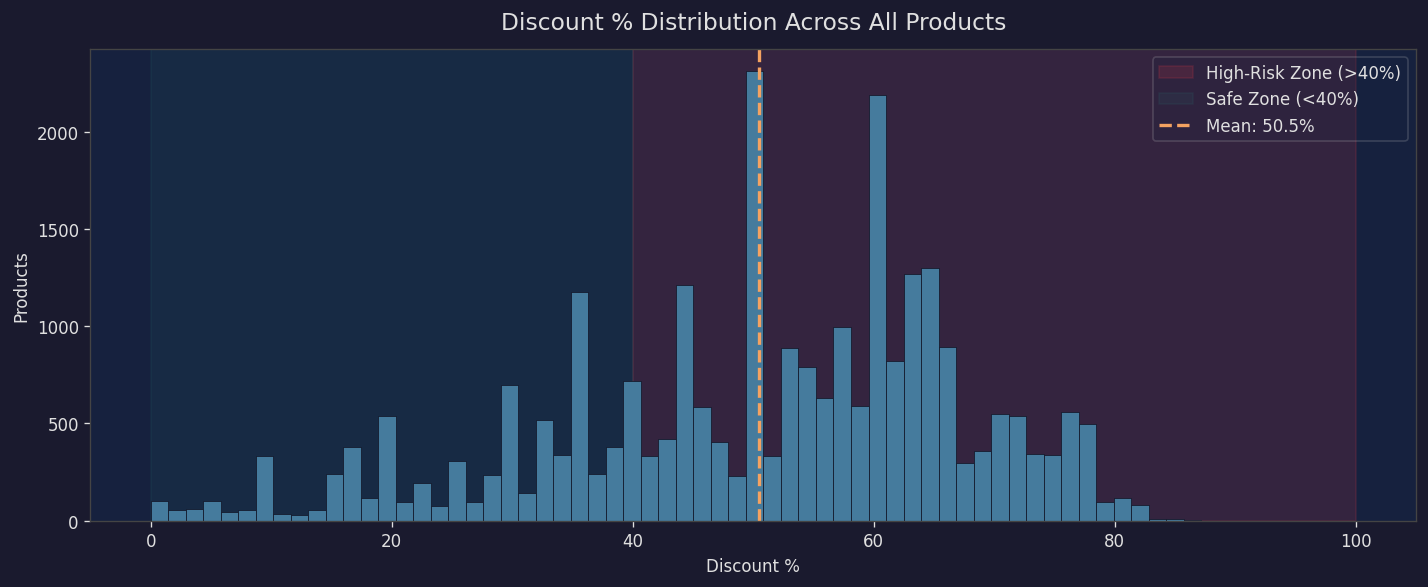

In [8]:

# Chart 1: Discount Distribution
fig, ax = plt.subplots(figsize=(12,5))
ax.axvspan(40,100,alpha=0.15,color='#E63946',label='High-Risk Zone (>40%)')
ax.axvspan(0,40, alpha=0.08,color='#2A9D8F',label='Safe Zone (<40%)')
ax.hist(df['discount_pct_calc'].dropna(),bins=60,color='#457B9D',edgecolor='#0d0d1e',lw=0.4)
ax.axvline(df['discount_pct_calc'].mean(),color='#F4A261',lw=2,ls='--',
           label=f"Mean: {df['discount_pct_calc'].mean():.1f}%")
ax.set_title('Discount % Distribution Across All Products',fontsize=14,pad=12)
ax.set_xlabel('Discount %'); ax.set_ylabel('Products')
ax.legend(framealpha=0.2); plt.tight_layout(); plt.show()


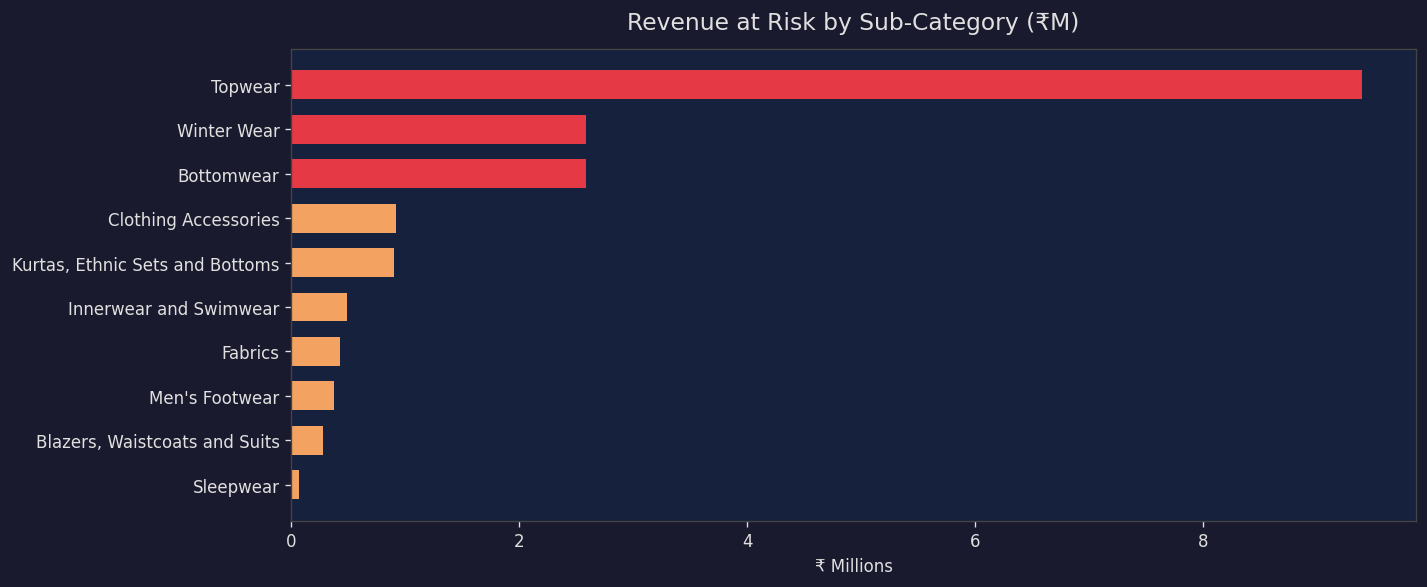

In [9]:

# Chart 2: Revenue at risk by sub-category
grp = df.groupby('sub_category')['revenue_at_risk'].sum().sort_values().tail(10)
fig, ax = plt.subplots(figsize=(12,5))
colors = ['#E63946' if v > grp.quantile(0.7) else '#F4A261' for v in grp.values]
ax.barh(grp.index, grp.values/1e6, color=colors, height=0.65)
ax.set_title('Revenue at Risk by Sub-Category (₹M)',fontsize=14,pad=12)
ax.set_xlabel('₹ Millions'); plt.tight_layout(); plt.show()


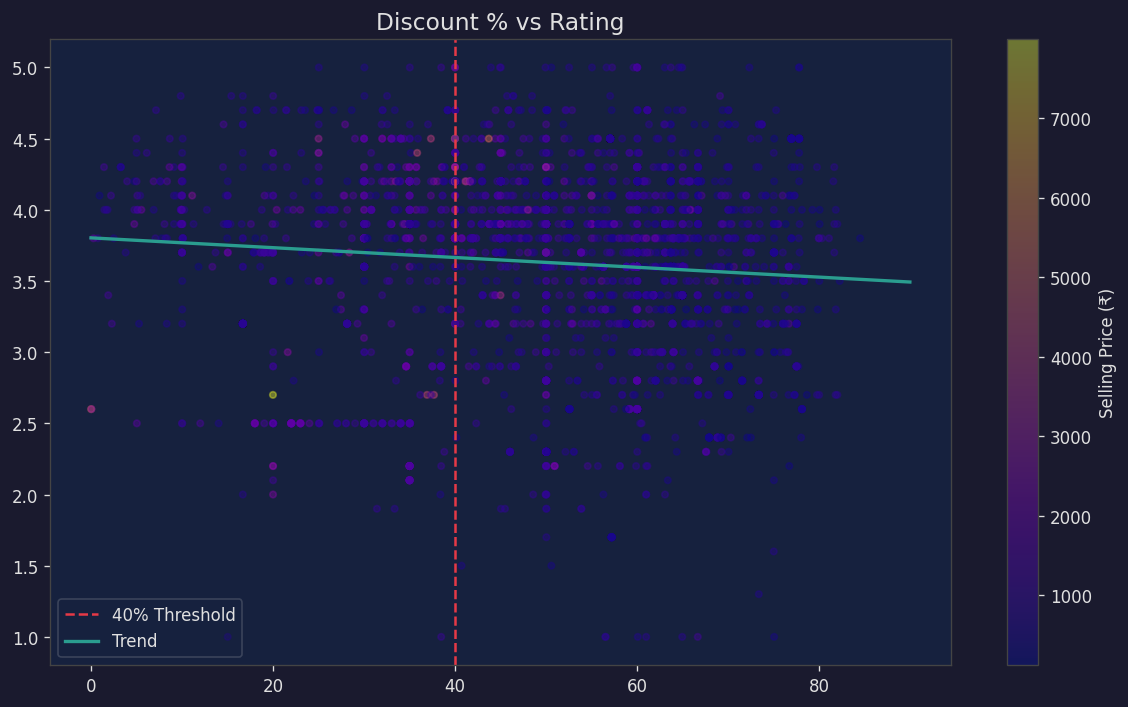

In [10]:

# Chart 3: Discount vs Rating (scatter)
sample = df.sample(3000, random_state=42)
fig, ax = plt.subplots(figsize=(10,6))
sc = ax.scatter(sample['discount_pct_calc'], sample['average_rating'],
                c=sample['selling_price'], cmap='plasma', alpha=0.4, s=15)
plt.colorbar(sc,ax=ax,label='Selling Price (₹)')
ax.axvline(40,color='#E63946',lw=1.5,ls='--',label='40% Threshold')
z = np.polyfit(sample.dropna(subset=['discount_pct_calc','average_rating'])['discount_pct_calc'],
               sample.dropna(subset=['discount_pct_calc','average_rating'])['average_rating'],1)
xp = np.linspace(0,90,100)
ax.plot(xp,np.poly1d(z)(xp),color='#2A9D8F',lw=2,label='Trend')
ax.set_title('Discount % vs Rating',fontsize=14); ax.legend(framealpha=0.2)
plt.tight_layout(); plt.show()


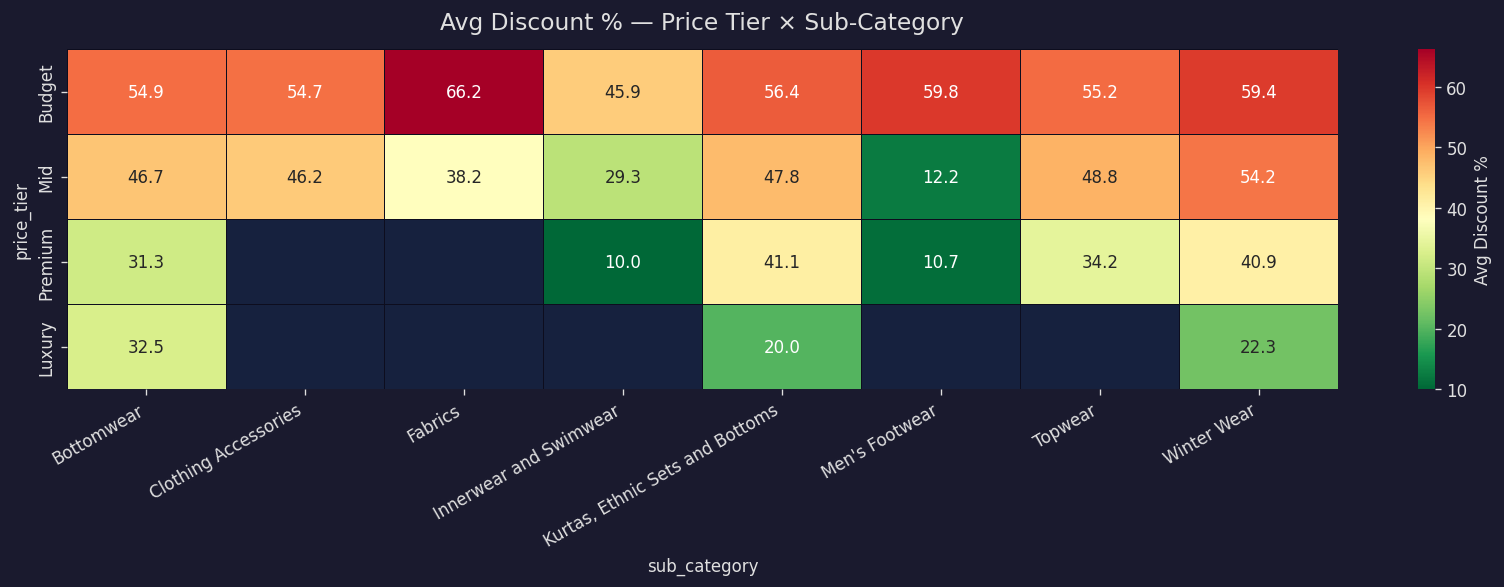

In [11]:

# Chart 4: Heatmap — price tier vs sub-category
top_subs = df['sub_category'].value_counts().head(8).index
pivot = df[df['sub_category'].isin(top_subs)].pivot_table(
    'discount_pct_calc','price_tier','sub_category','mean').round(1)
fig,ax = plt.subplots(figsize=(14,5))
sns.heatmap(pivot,annot=True,fmt='.1f',cmap='RdYlGn_r',linewidths=0.5,
            linecolor='#0d0d1e',ax=ax,cbar_kws={'label':'Avg Discount %'})
ax.set_title('Avg Discount % — Price Tier × Sub-Category',fontsize=14,pad=12)
plt.xticks(rotation=30,ha='right'); plt.tight_layout(); plt.show()


## 5. Business Recommendations

| # | Finding | Recommendation | Priority |
|---|---------|---------------|----------|
| 1 | **75% of products discounted >40%** | Cap seller discounts at 40% platform-wide | 🔴 Critical |
| 2 | **Topwear has ₹9.4M revenue at risk** | Implement category-specific max discount tiers | 🔴 Critical |
| 3 | **1,577 OOS items = ₹1.5M lost** | Enforce seller SLA for inventory restocking | 🟠 High |
| 4 | **High discounts don't improve ratings** | Use dynamic pricing instead of blanket discounts | 🟠 High |
| 5 | **Budget tier most over-discounted** | Repricing strategy: floor price = 60% of MRP | 🟡 Medium |
| 6 | **Some sellers avg >70% discount** | Require seller profitability score before listing | 🟡 Medium |

### 💡 Pricing Strategy Framework
- **Floor Price Rule:** `Selling Price ≥ 60% of MRP` for all categories
- **Smart Discounting:** Tie max discount % to category margin benchmarks  
- **OOS Penalty:** Auto-delist sellers with >10% OOS rate  
- **Profit-First Listing:** Require margin disclosure before product approval


## 6. Export Cleaned Data

In [ ]:

df.to_csv('../data/cleaned_data.csv', index=False)
print(f"Exported {len(df):,} rows to data/cleaned_data.csv")
print("\n=== FINAL SUMMARY ===")
print(f"Total Products      : {len(df):,}")
print(f"Revenue at Risk     : ₹{df['revenue_at_risk'].sum():,.0f}")
print(f"Over-Discounted     : {df['high_discount_flag'].sum():,} ({df['high_discount_flag'].mean()*100:.1f}%)")
print(f"OOS Revenue Loss    : ₹{df[df['out_of_stock']==True]['selling_price'].sum():,.0f}")
print(f"Avg Discount        : {df['discount_pct_calc'].mean():.1f}%")
print(f"Avg Rating          : {df['average_rating'].mean():.2f}")
